# 🇱🇰 Sri Lankan Currency Detector

**Detection method:** Convolutional Autoencoder reconstruction error (autoencoder only — no rule-based pipeline).

### Run order
| Cell | What it does | Run when |
|------|-------------|----------|
| 0 | Install packages | Once only |
| 1 | Imports & setup | Every session |
| 2 | Check dataset folders | Before training |
| 3 | Calibrate denomination detector | Once only |
| 4 | Train autoencoders | Once only (~10–20 min) |
| 5 | Calibrate thresholds | Once (re-run to retune) |
| 6 | Visual test — preprocessing | Optional |
| 7 | Full inference test | Optional |
| 8 | 🚀 Start web server | Every session |

## Cell 0 — Install packages
*Run once. Skip on later sessions.*

In [2]:
import sys
!{sys.executable} -m pip install --quiet \
    fastapi 'uvicorn[standard]' python-multipart \
    opencv-python numpy tensorflow matplotlib Pillow
print('✅ All packages installed')

✅ All packages installed


ERROR: Invalid requirement: "'uvicorn[standard]'": Expected package name at the start of dependency specifier
    'uvicorn[standard]'
    ^


## Cell 1 — Imports & setup
*Run this every session before starting the server.*

In [3]:
import os, sys, json, warnings, base64
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

PROJECT_ROOT = os.path.abspath('')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from config import DENOMINATIONS, SIDES, DATASET_DIR, MODELS_DIR, WARP_W, WARP_H

os.makedirs(MODELS_DIR, exist_ok=True)
print('✅ Setup complete')
print(f'   Project : {PROJECT_ROOT}')
print(f'   Dataset : {DATASET_DIR}')
print(f'   Models  : {MODELS_DIR}')

✅ Setup complete
   Project : d:\currency_detector_v3\final
   Dataset : d:\currency_detector_v3\final\dataset
   Models  : d:\currency_detector_v3\final\models


## Cell 2 — Check dataset folders
All 12 folders must exist and contain images before training.

Expected layout:
```
dataset/
├── 20_F/   20_B/
├── 50_F/   50_B/
├── 100_F/  100_B/
├── 500_F/  500_B/
├── 1000_F/ 1000_B/
└── 5000_F/ 5000_B/
```

In [4]:
print('Checking dataset folders ...\n')
total, missing = 0, []
exts = ('.jpg','.jpeg','.png','.bmp','.tiff')

for denom in DENOMINATIONS:
    for side in SIDES:
        folder = os.path.join(DATASET_DIR, f'{denom}_{side}')
        if not os.path.isdir(folder):
            missing.append(f'{denom}_{side}')
            print(f'  ❌  {denom}_{side:<8} — NOT FOUND')
            continue
        imgs = [f for f in os.listdir(folder) if f.lower().endswith(exts)]
        total += len(imgs)
        icon = '✅' if len(imgs) >= 50 else '⚠️ '
        print(f'  {icon}  {denom}_{side:<8} — {len(imgs):>4} images')

print(f'\n  Total images : {total}')
if missing:
    print(f'  ⚠️  Missing: {missing}')
else:
    print('  ✅  All 12 folders found — ready to proceed!')

Checking dataset folders ...

  ✅  20_F        —  148 images
  ✅  20_B        —  146 images
  ✅  50_F        —   50 images
  ✅  50_B        —  109 images
  ✅  100_F        —  107 images
  ✅  100_B        —  127 images
  ✅  500_F        —  113 images
  ✅  500_B        —  130 images
  ✅  1000_F        —  102 images
  ✅  1000_B        —  110 images
  ✅  5000_F        —  145 images
  ✅  5000_B        —  148 images

  Total images : 1435
  ✅  All 12 folders found — ready to proceed!


## Cell 3 — Calibrate denomination detector
Builds a mean 2D Hue+Saturation histogram per denomination from your genuine images.
**No model training needed** — runs in ~30 seconds.

In [5]:
from denomination_detector import calibrate

print('Building reference histograms ...\n')
calibrate(DATASET_DIR)
print('\n✅ Saved → models/denomination_histograms.json')

Building reference histograms ...

  Rs.20    → 148 images averaged
  Rs.50    → 50 images averaged
  Rs.100   → 107 images averaged
  Rs.500   → 113 images averaged
  Rs.1000  → 102 images averaged
  Rs.5000  → 145 images averaged

  Saved → d:\currency_detector_v3\final\models\denomination_histograms.json

✅ Saved → models/denomination_histograms.json


## Cell 4 — Train autoencoders
Trains **12 convolutional autoencoders** — one per denomination × side.
Uses **region-weighted reconstruction loss** (security feature zones weighted 3×).

⏱️ About **1 min per model** on CPU = **10–20 min total**.

💡 To test first with just one model, change `TRAIN_ONLY` below.

In [6]:
TRAIN_ONLY = [(500,'F'),(500,'B')]      # None = all 12.  Example: [(1000,'F'),(1000,'B')]
EPOCHS     = 30

import tensorflow as tf
from autoencoder import build_autoencoder, model_path
from train       import load_images, augment
from config      import AE_BATCH_SIZE, AE_PATIENCE

pairs = TRAIN_ONLY or [(d,s) for d in DENOMINATIONS for s in SIDES]
os.makedirs(MODELS_DIR, exist_ok=True)
log = []

for denom, side in pairs:
    print(f'\n{"═"*52}\n  Rs.{denom}  —  {side} side\n{"═"*52}')
    try:
        X        = augment(load_images(denom, side))
        n        = int(len(X) * 0.8)
        Xtr, Xv  = X[:n], X[n:]
        print(f'  Train: {len(Xtr)}   Val: {len(Xv)}')
        model    = build_autoencoder()
        mp       = model_path(denom, side)
        cbs = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=AE_PATIENCE,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7,
                min_lr=1e-6, verbose=0),
            tf.keras.callbacks.ModelCheckpoint(
                mp, monitor='val_loss', save_best_only=True, verbose=0),
        ]
        model.fit(Xtr, Xtr,
                  validation_data=(Xv, Xv),
                  epochs=EPOCHS,
                  batch_size=AE_BATCH_SIZE,
                  callbacks=cbs,
                  verbose=1)
        log.append((denom, side, '✅'))
        print(f'  ✅  Saved → {mp}')
    except Exception as e:
        log.append((denom, side, f'❌ {e}'))
        print(f'  ❌  FAILED: {e}')

print(f'\n{"═"*52}\n  SUMMARY')
for d, s, status in log:
    print(f'  {status}  Rs.{d}  {s}')
print('\n  ➡  Next: run Cell 5 to calibrate thresholds')


════════════════════════════════════════════════════
  Rs.500  —  F side
════════════════════════════════════════════════════
  Train: 361   Val: 91
Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.1087 - val_loss: 0.1049 - learning_rate: 0.0010
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1033 - val_loss: 0.0923 - learning_rate: 0.0010
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0897 - val_loss: 0.0824 - learning_rate: 0.0010
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0764 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0700 - val_loss: 0.0673 - learning_rate: 0.0010
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0642 - val_loss: 0.0645 - learning_rate: 0.0010
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0600 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0565 - val_loss: 0.0586 - 

## Cell 5 — Calibrate thresholds
Computes `threshold = mean_genuine_error + k × std_genuine_error`.

**Re-run this cell with a different k to retune without retraining:**
- `k = 3.0` — default, covers 99.7% of genuine notes
- `k = 2.5` — tighter, catches more fakes
- `k = 3.5` — looser, fewer false positives

In [7]:
K = 3.0    # ← only change this value to retune

from calibrate import calibrate_one

print(f'Calibrating thresholds  (k = {K}) ...\n')
summary = {}

for denom in DENOMINATIONS:
    for side in SIDES:
        try:
            r = calibrate_one(denom, side, K, DATASET_DIR)
            summary[f'{denom}_{side}'] = r
            print(f'  Rs.{denom:<5} {side}  '
                  f'threshold={r["threshold"]:.6f}  '
                  f'p99={r["p99"]:.6f}  '
                  f'n={r["n_images"]}')
        except Exception as e:
            print(f'  [SKIP] Rs.{denom} {side} — {e}')

summary_path = os.path.join(MODELS_DIR, 'thresholds.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n✅ Thresholds saved → {summary_path}')
print('\n  Hint: Too many false positives? Change K to 3.5 and re-run.')
print('  Hint: Missing fakes?          Change K to 2.5 and re-run.')

Calibrating thresholds  (k = 3.0) ...

  Rs.20    F  threshold=0.085824  p99=0.082084  n=148
  Rs.20    B  threshold=0.045573  p99=0.066302  n=146
  Rs.50    F  threshold=0.054181  p99=0.061332  n=50
  Rs.50    B  threshold=0.056739  p99=0.070300  n=109
  Rs.100   F  threshold=0.049793  p99=0.046607  n=107
  Rs.100   B  threshold=0.032384  p99=0.034044  n=127
  Rs.500   F  threshold=0.056395  p99=0.053527  n=113
  Rs.500   B  threshold=0.049981  p99=0.050023  n=130
  Rs.1000  F  threshold=0.058462  p99=0.065039  n=102
  Rs.1000  B  threshold=0.045189  p99=0.052974  n=110
  Rs.5000  F  threshold=0.042133  p99=0.054927  n=145
  Rs.5000  B  threshold=0.037213  p99=0.035624  n=148

✅ Thresholds saved → d:\currency_detector_v3\final\models\thresholds.json

  Hint: Too many false positives? Change K to 3.5 and re-run.
  Hint: Missing fakes?          Change K to 2.5 and re-run.


## Cell 6 — Visual test: preprocessing steps
Shows what the preprocessing pipeline does to one of your images.
Change `TEST_DENOM`, `TEST_SIDE`, `TEST_INDEX` to inspect any image.

Image: Orginal_20230511_085238.jpg  (328x153 px)
Output: (512, 1024, 3)  (1024x512 px)


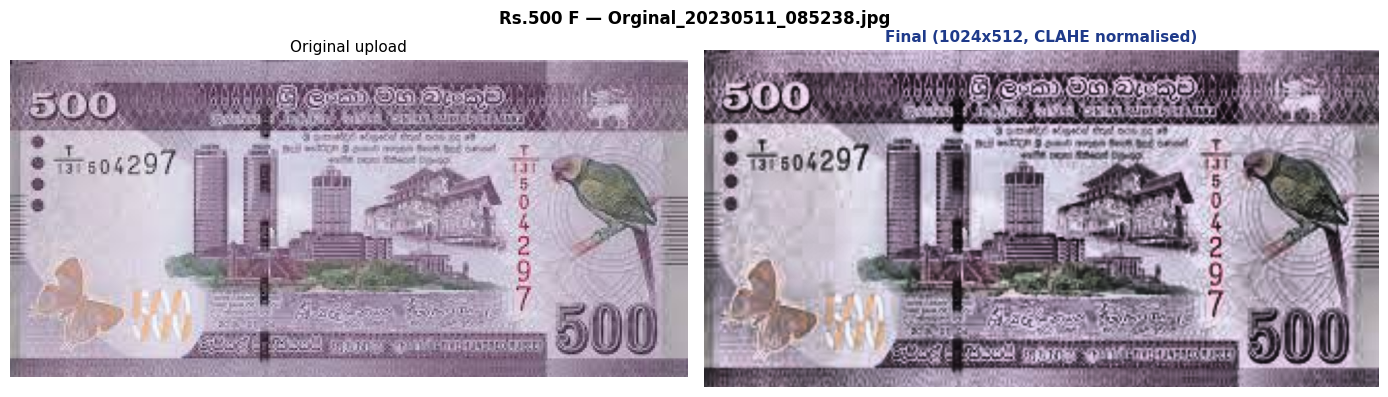

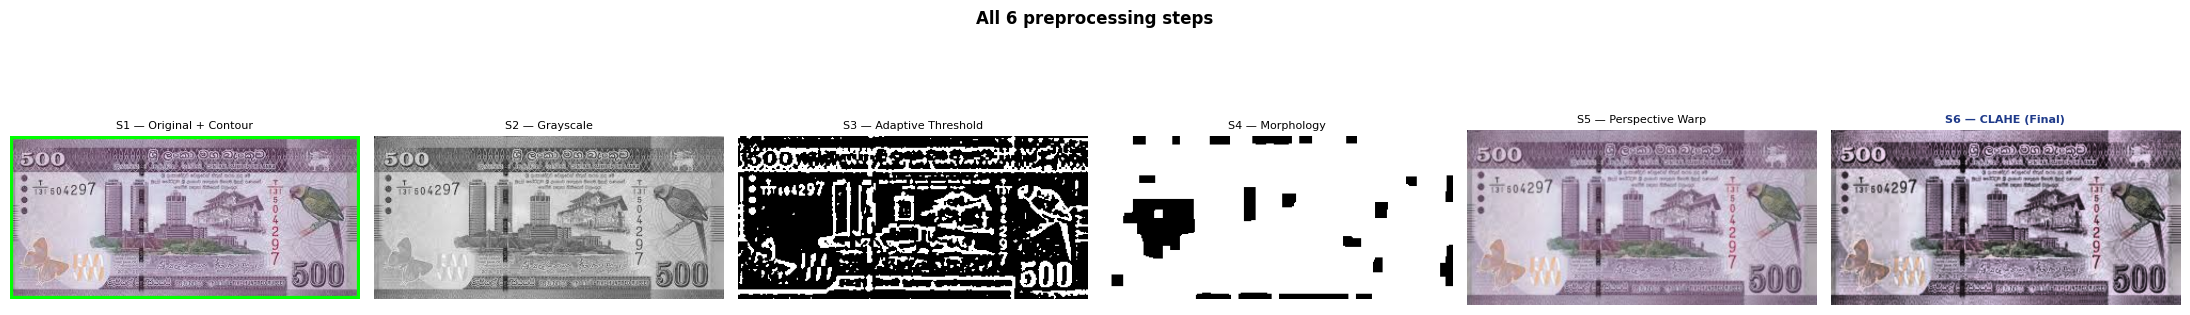

  Corners detected : True
  Fallback used    : False


In [8]:
TEST_DENOM = 500   # 20 / 50 / 100 / 500 / 1000 / 5000
TEST_SIDE  = 'F'    # 'F' = front,  'B' = back
TEST_INDEX = 0      # 0 = first image in folder

from preprocessing import preprocess

folder   = os.path.join(DATASET_DIR, f'{TEST_DENOM}_{TEST_SIDE}')
all_imgs = sorted([f for f in os.listdir(folder)
                   if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
raw      = cv2.imread(os.path.join(folder, all_imgs[TEST_INDEX]))

print(f'Image: {all_imgs[TEST_INDEX]}  ({raw.shape[1]}x{raw.shape[0]} px)')

# debug=True returns (bgr, hsv, steps)
# steps is a dict with keys step1_original ... step6_clahe (each is base64 PNG)
result = preprocess(raw, debug=True)


bgr, hsv, steps = preprocess(raw, debug=True)  # ✅ unpack the tuple

if bgr is None:
    print('Preprocessing failed — try a different image')
else:
    print(f'Output: {bgr.shape}  ({WARP_W}x{WARP_H} px)')

    # Helper — decode a base64 step image for matplotlib
    def decode_step(b64_str):
        arr = np.frombuffer(base64.b64decode(b64_str), np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Original vs Final side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    ax1.set_title('Original upload', fontsize=11)
    ax1.axis('off')
    ax2.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax2.set_title(f'Final ({WARP_W}x{WARP_H}, CLAHE normalised)',
                  fontsize=11, color='#1e3a8a', fontweight='bold')
    ax2.axis('off')
    plt.suptitle(f'Rs.{TEST_DENOM} {TEST_SIDE} — {all_imgs[TEST_INDEX]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # All 6 steps as individual images
    step_labels = [
        ('step1_original',   'S1 — Original + Contour'),
        ('step2_grayscale',  'S2 — Grayscale'),
        ('step3_threshold',  'S3 — Adaptive Threshold'),
        ('step4_morphology', 'S4 — Morphology'),
        ('step5_warp',       'S5 — Perspective Warp'),
        ('step6_clahe',      'S6 — CLAHE (Final)'),
    ]

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    for ax, (key, label) in zip(axes, step_labels):
        ax.imshow(decode_step(steps[key]))
        isFinal = key == 'step6_clahe'
        ax.set_title(label, fontsize=8,
                     color='#1e3a8a' if isFinal else 'black',
                     fontweight='bold' if isFinal else 'normal')
        ax.axis('off')

    plt.suptitle('All 6 preprocessing steps', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'  Corners detected : {steps["corners_detected"]}')
    print(f'  Fallback used    : {steps["fallback_used"]}')

## Cell 7 — Full inference test
Runs the complete end-to-end pipeline on a front+back pair from your dataset.
Shows verdict, per-side scores, and the preprocessed images.

Front : Orginal_20230511_193813.jpg
Back  : Orginal_20230511_194357.jpg
Running ...

════════════════════════════════════════════════════
  ✅  VERDICT         : GENUINE
  💵  Denomination    : Rs. 100  (64.3% confident)
  🤖  Overall conf.   : 82.5%
────────────────────────────────────────────────────
  FRONT  score      : 80.1%
         error      : 0.019814
         threshold  : 0.049793
         result     : ✅ Below threshold
────────────────────────────────────────────────────
  BACK   score      : 84.9%
         error      : 0.009784
         threshold  : 0.032384
         result     : ✅ Below threshold
════════════════════════════════════════════════════


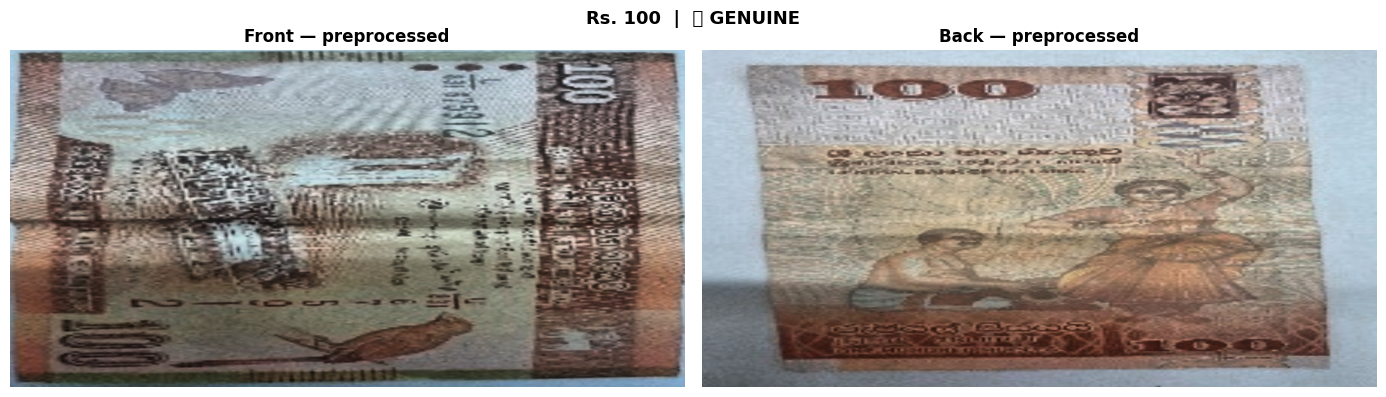

In [9]:
TEST_DENOM = 100
TEST_INDEX = 0

from inference import analyse_bytes

def read_bytes(denom, side, index):
    folder   = os.path.join(DATASET_DIR, f'{denom}_{side}')
    all_imgs = sorted([f for f in os.listdir(folder)
                       if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
    path = os.path.join(folder, all_imgs[index])
    with open(path,'rb') as f: return f.read(), all_imgs[index]

front_bytes, fname_f = read_bytes(TEST_DENOM, 'F', TEST_INDEX)
back_bytes,  fname_b = read_bytes(TEST_DENOM, 'B', TEST_INDEX)

print(f'Front : {fname_f}')
print(f'Back  : {fname_b}')
print('Running ...\n')

r = analyse_bytes(front_bytes, back_bytes)

icon = {'GENUINE':'✅','UNCERTAIN':'⚠️','SUSPICIOUS':'❌'}.get(r['verdict'],'❓')

print(f'{"═"*52}')
print(f'  {icon}  VERDICT         : {r["verdict"]}')
print(f'  💵  Denomination    : {r["denomination"]}  ({r["denom_conf"]}% confident)')
print(f'  🤖  Overall conf.   : {r["model_conf"]}%')
print(f'{"─"*52}')
print(f'  FRONT  score      : {r["front_conf"]}%')
print(f'         error      : {r["front_error"]:.6f}')
print(f'         threshold  : {r["front_thresh"]:.6f}')
print(f'         result     : {"✅ Below threshold" if r["front_error"] <= r["front_thresh"] else "❌ Above threshold"}')
print(f'{"─"*52}')
print(f'  BACK   score      : {r["back_conf"]}%')
print(f'         error      : {r["back_error"]:.6f}')
print(f'         threshold  : {r["back_thresh"]:.6f}')
print(f'         result     : {"✅ Below threshold" if r["back_error"] <= r["back_thresh"] else "❌ Above threshold"}')
print(f'{"═"*52}')

# Show preprocessed pair
def show_b64(b64):
    arr = np.frombuffer(base64.b64decode(b64), np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.imshow(show_b64(r['preprocess_front']['final']))
ax1.set_title('Front — preprocessed', fontweight='bold')
ax1.axis('off')
ax2.imshow(show_b64(r['preprocess_back']['final']))
ax2.set_title('Back — preprocessed', fontweight='bold')
ax2.axis('off')
plt.suptitle(f'{r["denomination"]}  |  {icon} {r["verdict"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 8 — 🚀 Start web server
Runs FastAPI in a background thread. **Keep this cell running.**

Open your browser at **[http://localhost:8000](http://localhost:8000)**

To stop: **Kernel → Interrupt** or **Kernel → Restart**

In [10]:
import threading, time, uvicorn
from api import app

config = uvicorn.Config(
    app, host='0.0.0.0', port=8000,
    log_level='info', loop='asyncio'
)
server = uvicorn.Server(config)
thread = threading.Thread(target=server.run, daemon=True)
thread.start()
time.sleep(2)

display(HTML('''
<div style="padding:20px 24px;background:#f0fdf4;border:2px solid #86efac;
            border-radius:12px;font-family:Arial,sans-serif;max-width:460px">
  <h3 style="color:#15803d;margin:0 0 10px">✅ Server is running!</h3>
  <p style="margin:0 0 6px">Open your browser at<br/>
    <a href="http://localhost:8000" target="_blank"
       style="color:#1a56db;font-weight:bold;font-size:1.1rem">
      http://localhost:8000
    </a>
  </p>
  <p style="margin:8px 0 0;font-size:.82rem;color:#6b7280">
    API docs:
    <a href="http://localhost:8000/docs" target="_blank" style="color:#1a56db">
      http://localhost:8000/docs
    </a>
  </p>
</div>
'''))

thread.join()

INFO:     Started server process [20940]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('0.0.0.0', 8000): only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
